In [1]:
import os
import pandas as pd
import squidpy as sq
import scanpy as sc
import multiprocessing
import warnings
import scipy
import json
import numpy as np
from vitessce.data_utils import (
    to_diamond,
    rgb_img_to_ome_zarr,
    optimize_adata,
)

/usr/local/lib/python3.10/dist-packages/dask/dataframe/__init__.py:31: FutureWarning: The legacy Dask DataFrame implementation is deprecated and will be removed in a future version. Set the configuration option `dataframe.query-planning` to `True` or None to enable the new Dask Dataframe implementation and silence this warning.
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/anndata/utils.py:429: FutureWarning: Importing read_text from `anndata` is deprecated. Import anndata.io.read_text instead.
  warnings.warn(msg, FutureWarning)
/usr/local/lib/python3.10/dist-packages/vitessce/__init__.py:42: UserWarning: Extra installs are necessary to use widgets: No module named 'anywidget'
  warn(f'Extra installs are necessary to use widgets: {e}')
/usr/local/lib/python3.10/dist-packages/vitessce/__init__.py:68: UserWarning: Extra installs are necessary to use exports: No module named 'starlette'
  warn(f'Extra installs are necessary to use exports: {e}')


In [2]:
OUT_DIR = "/data/zusers/kresgeb/hippocampus/testing"

In [3]:
spe = sc.read_h5ad("/data/zusers/kresgeb/hippocampus/python_converted/spe.h5ad")
spe

AnnData object with n_obs × n_vars = 150917 × 31483
    obs: 'sample_id', 'in_tissue', 'array_row', 'array_col', '10x_graphclust', '10x_kmeans_10_clusters', '10x_kmeans_2_clusters', '10x_kmeans_3_clusters', '10x_kmeans_4_clusters', '10x_kmeans_5_clusters', '10x_kmeans_6_clusters', '10x_kmeans_7_clusters', '10x_kmeans_8_clusters', '10x_kmeans_9_clusters', 'key', 'sum_umi', 'sum_gene', 'expr_chrM', 'expr_chrM_ratio', 'ManualAnnotation', 'brnum', 'dateImg', 'experimenterImg', 'slide', 'array', 'position', 'seqNum', 'experimenterSeq', 'dx', 'race', 'sex', 'age', 'pmi', 'sum', 'detected', 'subsets_Mito_sum', 'subsets_Mito_detected', 'subsets_Mito_percent', 'total', 'low_sum_id', 'low_sum_br', 'low_detected_id', 'low_detected_br', 'discard_auto_br', 'discard_auto_id', 'sizeFactor', 'cluster', 'neuron_cell_body', 'domain', 'broad.domain', 'nmf1', 'nmf2', 'nmf3', 'nmf4', 'nmf5', 'nmf6', 'nmf7', 'nmf8', 'nmf9', 'nmf10', 'nmf11', 'nmf12', 'nmf13', 'nmf14', 'nmf15', 'nmf16', 'nmf17', 'nmf18', 'nm

In [4]:
def split_by_sample_id(spe):
    """
    Splits the AnnData object by sample ID and returns a dictionary of AnnData objects.
    """
    sample_dict = {}
    for sample_id in spe.obs["sample_id"].unique():
        subset = spe[spe.obs["sample_id"] == sample_id].copy()
        sample_dict[sample_id] = subset
    return sample_dict

In [5]:
sample_ids = spe.obs["sample_id"].unique()
# TODO: remove blacklisted sample IDs once I resolve the GSM8226210 issue
# sample_id_blacklist = ["V10B01-086_D1", "V10B01-086_C1"]
# sample_ids = [sid for sid in sample_ids if sid not in sample_id_blacklist]
samples_adata = split_by_sample_id(spe)


In [6]:
# Since the RData to h5ad conversion removes the image and coordinates, we need to add them back in for each sample
# We will do so by loading visium outputs (SpaceRanger format) for each sample and adding the image and coordinates to the corresponding AnnData object
# We have the /data/zusers/kresgeb/hippocampus/geo_reformatted/srt/ dir with subfolders like
# /data/zusers/kresgeb/hippocampus/geo_reformatted/srt/GSM8226199_V12F14-051_A1/outs while sample_ids are like V12F14-051_A1
# The GSM8226199_-like prefix is different for each sample, so we will need to match the sample_id to the corresponding folder using a contains or endswith check

def add_image_and_coordinates(sample_id, adata):
    """
    Adds image and coordinates to the AnnData object based on the sample ID.
    """

    print(f"Adding image and coordinates for sample ID: {sample_id}")
    # Find the corresponding folder for the sample_id
    # Assuming the folder structure is like /data/zusers/kresgeb/hippocampus/geo_reformatted/srt/GSM_[SOMENUMBERS]_<sample_id>/outs
    base_path = "/data/zusers/kresgeb/hippocampus/geo_reformatted/srt"
    folder_path = None
    for folder in os.listdir(base_path):
        if folder.startswith("GSM8226210"): # Rough accounting for weird GSM collision detailed in scratch
            continue
        if folder.endswith(sample_id):
            folder_path = os.path.join(base_path, folder)
            break
    
    if folder_path is None or not os.path.exists(folder_path):
        print(f"ERROR!--Folder not found for sample ID: {sample_id}")
        return adata
    
    outs_folder = os.path.join(folder_path, "outs")

    if not os.path.exists(outs_folder):
        print(f"ERROR!--'outs' folder not found for sample ID: {sample_id}")
        return adata
    
    
    # Load the raw geo visium data using squidpy
    # This will be the source of image data and spatial coordinates for the AnnData object
    # We assume the counts file is named "matrix.mtx.gz" as per SpaceRanger standard
    geo_adata = sq.read.visium(
    outs_folder, 
    library_id=sample_id, # Needed to avoid issues with library_id check (not used, but checked against None before .mtz.gz suffix)
    counts_file="matrix.mtx.gz",
    load_images=True
)
    
    # ----- Add back the spatial data that was removed during conversion -------

    # Strip adata barcodes after first underscore to match raw geo barcodes
    adata_barcodes_stripped = adata.obs_names.str.split("_").str[0]
    
    # Get indices of adata barcodes in geo_adata.obs_names
    idx = geo_adata.obs_names.get_indexer(adata_barcodes_stripped)

    # Spots in adata missing from geo_adata
    missing_mask = (idx == -1)
    if missing_mask.any():
        missing = adata.obs_names[missing_mask]
        print(f"WARNING: {len(missing)} barcodes in adata not found in geo_adata. Examples:\n", missing[:min(10, len(missing))].tolist())
    
    # Spots in geo_adata missing from adata (reverse check)
    geo_missing = geo_adata.obs_names[~geo_adata.obs_names.isin(adata_barcodes_stripped)]
    if len(geo_missing) > 0:
        print(f"INFO: {len(geo_missing)} barcodes in geo_adata (raw GEO Accession derived) not present in adata.")
    
    # Assign spatial coordinates from geo_adata, filtered and reordered to match adata
    adata.obsm["spatial"] = geo_adata.obsm["spatial"][idx]
    # Assign image data from geo_adata to adata
    adata.uns["spatial"] = geo_adata.uns["spatial"]

    # ------------------- End of adding spatial data -------------

    return adata


In [7]:
def process_sample(sample_id, adata):
    """
    Processes a single sample by adding image and coordinates.
    """
    print(f"Processing sample: {sample_id}")
    return add_image_and_coordinates(sample_id, adata)

In [8]:
for sample_id in sample_ids:
    adata = samples_adata[sample_id]
    samples_adata[sample_id] = process_sample(sample_id, adata)

Processing sample: V10B01-086_D1
Adding image and coordinates for sample ID: V10B01-086_D1
INFO: 1603 barcodes in geo_adata (raw GEO Accession derived) not present in adata.
Processing sample: V10B01-086_C1
Adding image and coordinates for sample ID: V10B01-086_C1
INFO: 2386 barcodes in geo_adata (raw GEO Accession derived) not present in adata.
Processing sample: V11U08-081_C1
Adding image and coordinates for sample ID: V11U08-081_C1
ERROR!--Folder not found for sample ID: V11U08-081_C1
Processing sample: V11U08-081_D1
Adding image and coordinates for sample ID: V11U08-081_D1
ERROR!--Folder not found for sample ID: V11U08-081_D1
Processing sample: V11L05-333_A1
Adding image and coordinates for sample ID: V11L05-333_A1
INFO: 23 barcodes in geo_adata (raw GEO Accession derived) not present in adata.
Processing sample: V11L05-333_B1
Adding image and coordinates for sample ID: V11L05-333_B1
INFO: 7 barcodes in geo_adata (raw GEO Accession derived) not present in adata.
Processing sample: 

In [9]:
sample_ids

['V10B01-086_D1', 'V10B01-086_C1', 'V11U08-081_C1', 'V11U08-081_D1', 'V11L05-333_A1', ..., 'V11L05-336_D1', 'V12F14-051_C1', 'V12F14-051_D1', 'V12F14-051_A1', 'V12F14-051_B1']
Length: 36
Categories (36, object): ['V10B01-085_A1', 'V10B01-085_B1', 'V10B01-085_C1', 'V10B01-085_D1', ..., 'V12F14-051_A1', 'V12F14-051_B1', 'V12F14-051_C1', 'V12F14-051_D1']

In [10]:
test = samples_adata["V10B01-086_D1"]

In [11]:
hires_image = test.uns["spatial"]["V10B01-086_D1"]["images"]["hires"]
print(hires_image.shape)
hires_image

(1945, 2000, 3)


array([[[241, 243, 243],
        [242, 244, 243],
        [242, 244, 244],
        ...,
        [241, 244, 243],
        [241, 244, 243],
        [241, 244, 243]],

       [[241, 243, 243],
        [241, 243, 243],
        [242, 244, 243],
        ...,
        [241, 244, 243],
        [241, 244, 243],
        [241, 243, 243]],

       [[241, 243, 242],
        [241, 243, 243],
        [242, 244, 243],
        ...,
        [241, 244, 243],
        [241, 244, 243],
        [241, 243, 243]],

       ...,

       [[240, 240, 240],
        [240, 240, 240],
        [240, 240, 240],
        ...,
        [240, 240, 240],
        [240, 240, 240],
        [240, 240, 240]],

       [[240, 240, 240],
        [240, 240, 240],
        [240, 240, 240],
        ...,
        [240, 240, 240],
        [240, 240, 240],
        [240, 240, 240]],

       [[240, 240, 240],
        [240, 240, 240],
        [240, 240, 240],
        ...,
        [240, 240, 240],
        [240, 240, 240],
        [240, 240, 240]]

In [12]:
spe2 = sc.read_h5ad("/data/zusers/kresgeb/hippocampus/python_converted/spe_2.h5ad")
spe2

AnnData object with n_obs × n_vars = 150917 × 31483
    obs: 'sample_id', 'in_tissue', 'array_row', 'array_col', '10x_graphclust', '10x_kmeans_10_clusters', '10x_kmeans_2_clusters', '10x_kmeans_3_clusters', '10x_kmeans_4_clusters', '10x_kmeans_5_clusters', '10x_kmeans_6_clusters', '10x_kmeans_7_clusters', '10x_kmeans_8_clusters', '10x_kmeans_9_clusters', 'key', 'sum_umi', 'sum_gene', 'expr_chrM', 'expr_chrM_ratio', 'ManualAnnotation', 'brnum', 'dateImg', 'experimenterImg', 'slide', 'array', 'position', 'seqNum', 'experimenterSeq', 'dx', 'race', 'sex', 'age', 'pmi', 'sum', 'detected', 'subsets_Mito_sum', 'subsets_Mito_detected', 'subsets_Mito_percent', 'total', 'low_sum_id', 'low_sum_br', 'low_detected_id', 'low_detected_br', 'discard_auto_br', 'discard_auto_id', 'sizeFactor', 'cluster', 'neuron_cell_body', 'domain', 'broad.domain', 'nmf1', 'nmf2', 'nmf3', 'nmf4', 'nmf5', 'nmf6', 'nmf7', 'nmf8', 'nmf9', 'nmf10', 'nmf11', 'nmf12', 'nmf13', 'nmf14', 'nmf15', 'nmf16', 'nmf17', 'nmf18', 'nm

In [13]:
test2 = spe2[spe2.obs["sample_id"] == "V10B01-086_D1"].copy()

In [26]:
hires_image2 = test2.uns["spatial"]["V10B01-086_D1"]["images"]["hires"]
print(hires_image2.shape)
hires_image2

(2000, 1945, 3)


array([[[241, 244, 243],
        [241, 243, 243],
        [241, 243, 243],
        ...,
        [240, 240, 240],
        [240, 240, 240],
        [240, 240, 240]],

       [[241, 244, 243],
        [241, 244, 243],
        [241, 244, 243],
        ...,
        [240, 240, 240],
        [240, 240, 240],
        [240, 240, 240]],

       [[241, 244, 243],
        [241, 244, 243],
        [241, 244, 243],
        ...,
        [240, 240, 240],
        [240, 240, 240],
        [240, 240, 240]],

       ...,

       [[242, 244, 244],
        [242, 244, 243],
        [242, 244, 243],
        ...,
        [240, 240, 240],
        [240, 240, 240],
        [240, 240, 240]],

       [[242, 244, 243],
        [241, 243, 243],
        [241, 243, 243],
        ...,
        [240, 240, 240],
        [240, 240, 240],
        [240, 240, 240]],

       [[241, 243, 243],
        [241, 243, 243],
        [241, 243, 242],
        ...,
        [240, 240, 240],
        [240, 240, 240],
        [240, 240, 240]]

In [15]:
# spe3 = sc.read_h5ad("/data/zusers/kresgeb/hippocampus/python_converted/spe_3.h5ad")
# spe3

In [16]:
# test3 = spe3[spe3.obs["sample_id"] == "V10B01-086_D1"].copy()

In [17]:
# def check_spatial_alignment(adata, ref=None):
#     spatial = adata.obsm["spatial"]
#     if hasattr(spatial, "loc"):  # DataFrame
#         return np.all(spatial.index == adata.obs.index)
#     elif ref is not None:
#         return np.all(spatial == ref)
#     else:
#         raise ValueError("Spatial is NumPy array with no reference given.")

# print(check_spatial_alignment(test2))

In [18]:
# import numpy as np
# import pandas as pd

# # Make sure obs.index match
# assert np.array_equal(test2.obs.index, test3.obs.index), "Indexes do not match!"

# # Compare spatial coordinates
# spatial_diff = test2.obsm["spatial"] - test3.obsm["spatial"]
# max_diff = np.max(np.abs(spatial_diff))
# print("Maximum difference in spatial coordinates:", max_diff)

# # Optionally, print rows where there’s any difference
# rows_with_diff = np.where(np.any(spatial_diff != 0, axis=1))[0]
# print(f"Number of spots with any coordinate difference: {len(rows_with_diff)}")
# if len(rows_with_diff) > 0:
#     # show first few
#     pd.DataFrame({
#         "test2_x": test2.obsm["spatial"][rows_with_diff, 0],
#         "test2_y": test2.obsm["spatial"][rows_with_diff, 1],
#         "test3_x": test3.obsm["spatial"][rows_with_diff, 0],
#         "test3_y": test3.obsm["spatial"][rows_with_diff, 1],
#     }).head(10)

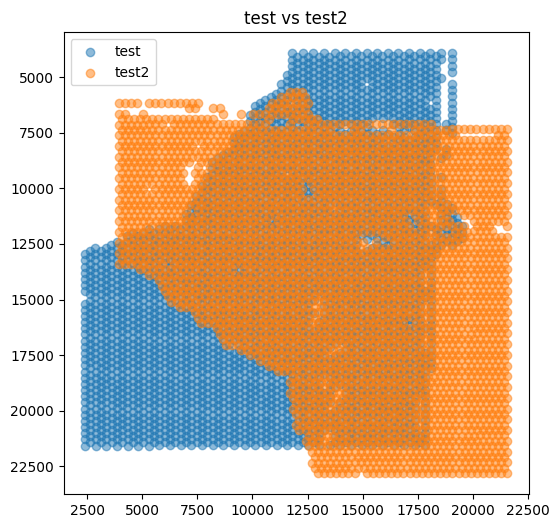

In [19]:
import matplotlib.pyplot as plt

# # Convert test2.obsm["spatial"] to numpy
# spatial2 = test2.obsm["spatial"].to_numpy()  # or .values

# plt.scatter(test.obsm["spatial"][:,0], test.obsm["spatial"][:,1], alpha=0.5, label="test")
# plt.scatter(spatial2[:,0], spatial2[:,1], alpha=0.5, label="test2")
# plt.gca().invert_yaxis()
# plt.title("test vs test2")
# plt.legend()
# plt.show()

# Plot test vs test2
plt.figure(figsize=(6,6))
plt.scatter(test.obsm["spatial"][:,0], test.obsm["spatial"][:,1], alpha=0.5, label="test")
plt.scatter(test2.obsm["spatial"][:,0], test2.obsm["spatial"][:,1], alpha=0.5, label="test2")
plt.gca().invert_yaxis()
plt.title("test vs test2")
plt.legend()
plt.show()

# # Plot test2 vs test3
# plt.figure(figsize=(6,6))
# plt.scatter(spatial2[:,0], spatial2[:,1], alpha=0.5, label="test2")
# plt.scatter(test3.obsm["spatial"][:,0], test3.obsm["spatial"][:,1], alpha=0.5, label="test3")
# plt.gca().invert_yaxis()
# plt.title("test2 vs test3")
# plt.legend()
# plt.show()

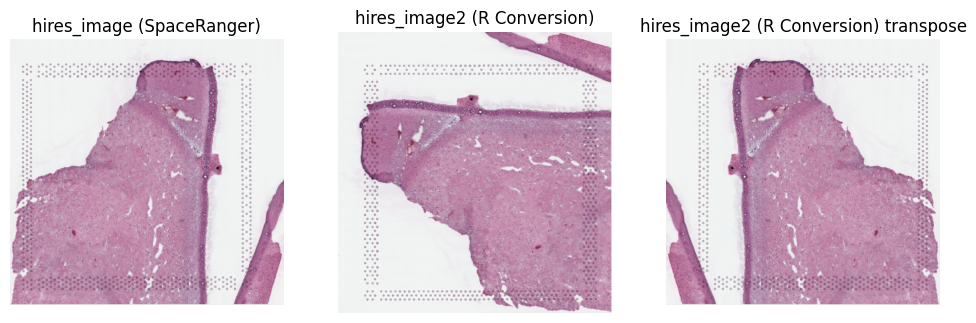

In [27]:
import matplotlib.pyplot as plt
import numpy as np

# Assume hires_img and hires_img2 are your two images
# If shapes differ, optionally transpose the R-converted image to match
# hires_img_aligned = np.transpose(hires_img, (1, 0, 2))

plt.figure(figsize=(12,6))

# Left: hires_img
plt.subplot(1,3,1)
plt.imshow(hires_image)  # or hires_img_aligned if transposed
plt.title("hires_image (SpaceRanger)")
plt.axis('off')

# Middle: hires_img2
plt.subplot(1,3,2)
plt.imshow(hires_image2)
plt.title("hires_image2 (R Conversion)")
plt.axis('off')

# Transpose R-converted image to match SpaceRanger orientation
hires_image2_aligned = np.transpose(hires_image2, (1, 0, 2))

# Right: hires_img2 transposed
plt.subplot(1,3,3)
plt.imshow(hires_image2_aligned)
plt.title("hires_image2 (R Conversion) transpose")
plt.axis('off')


plt.show()


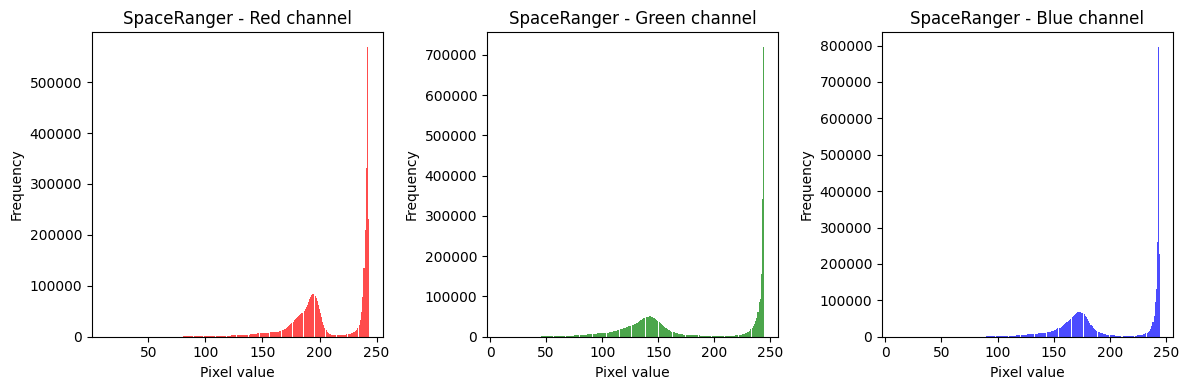

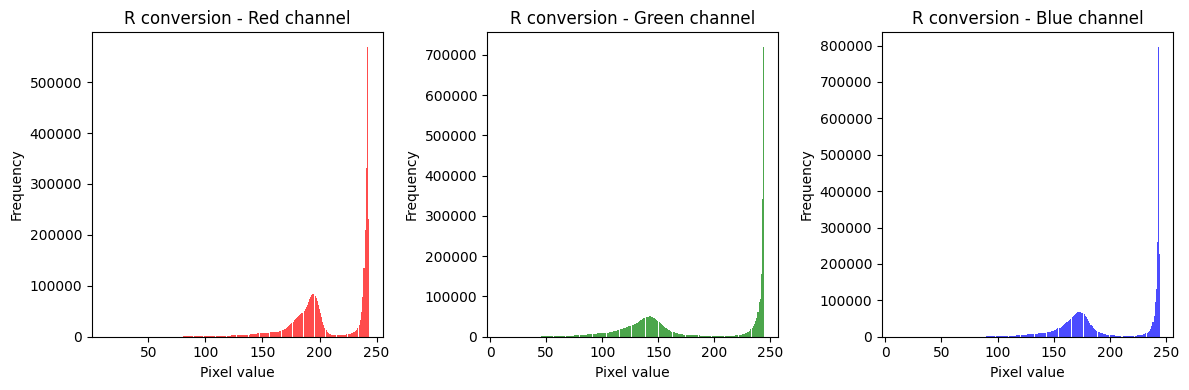

In [21]:
# Images: highres_image (SpaceRanger), hires_image2 (R conversion)
images = {
    "SpaceRanger": hires_image,
    "R conversion": hires_image2
}

# Plot histograms per channel
for name, img in images.items():
    plt.figure(figsize=(12,4))
    for ch, color in enumerate(['Red','Green','Blue']):
        channel_data = img[:,:,ch].ravel()  # flatten
        plt.subplot(1,3,ch+1)
        plt.hist(channel_data, bins=256, color=color.lower(), alpha=0.7)
        plt.title(f"{name} - {color} channel")
        plt.xlabel("Pixel value")
        plt.ylabel("Frequency")
    plt.tight_layout()
    plt.show()

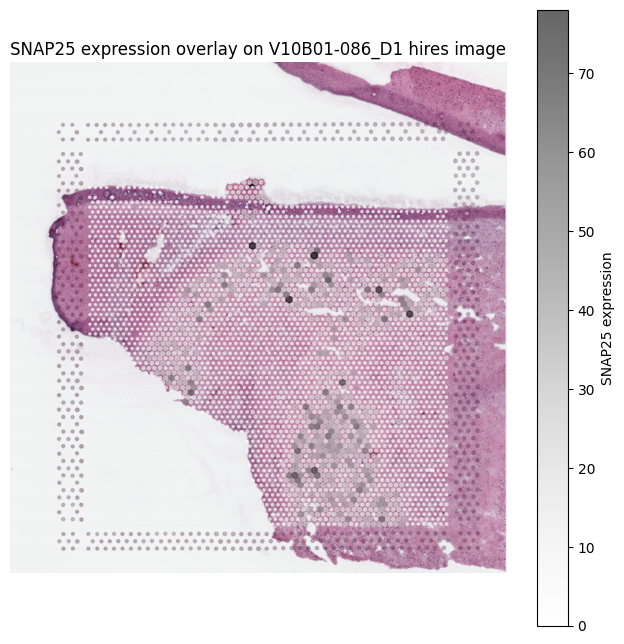

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Parameters
gene = "SNAP25"
sample_id = "V10B01-086_D1"

# Extract hires image and scale factor from .uns
hires_img = test2.uns["spatial"][sample_id]["images"]["hires"]
scale = test2.uns["spatial"][sample_id]["scalefactors"]["tissue_hires_scalef"]

# Extract spatial coordinates and expression
coords = test2.obsm["spatial"]
expr = test2[:, gene].X

# Convert sparse to dense if needed
if hasattr(expr, "toarray"):
    expr = expr.toarray().flatten()
else:
    expr = np.ravel(expr)

# Scale coordinates to image pixels
coords_px = coords * scale

# Optional: scale expression for point size
expr_scaled = 20 * (expr / np.max(expr)) + 2

# Plot
plt.figure(figsize=(8, 8))
plt.imshow(hires_img)
plt.scatter(coords_px[:, 0], coords_px[:, 1], c=expr, s=expr_scaled,
            cmap="Grays", alpha=0.6)
#plt.gca().invert_yaxis()  # y-axis origin at top-left
plt.colorbar(label=f"{gene} expression")
plt.title(f"{gene} expression overlay on {sample_id} hires image")
plt.axis('off')
plt.show()


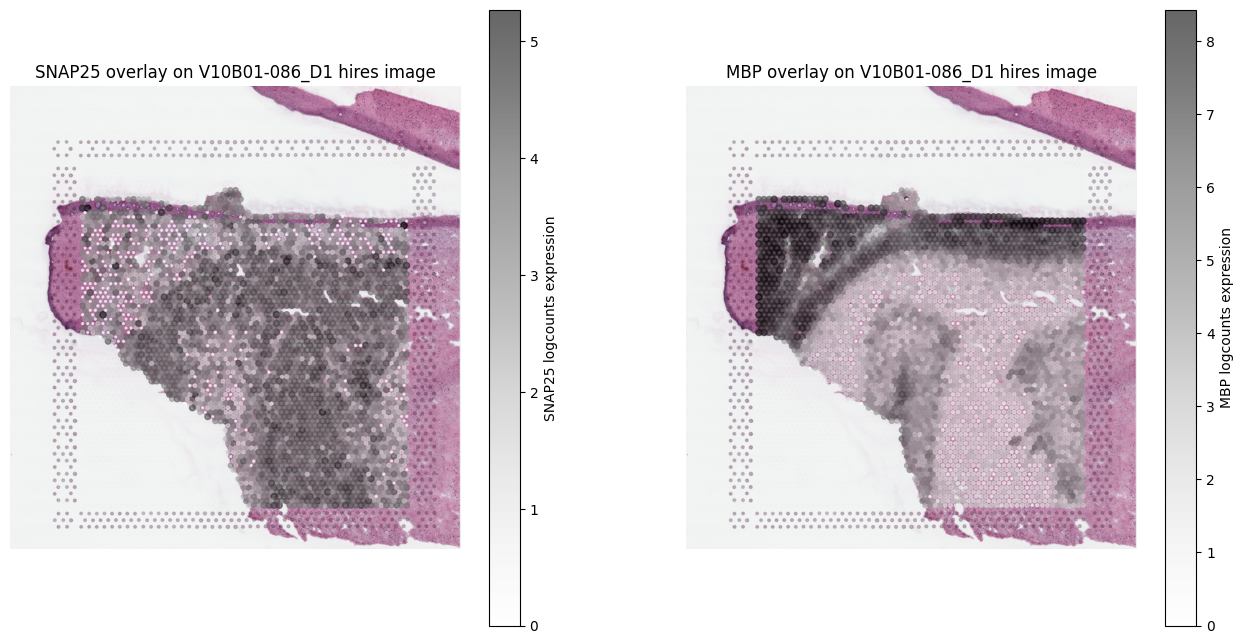

In [40]:
import numpy as np
import matplotlib.pyplot as plt

genes = ["SNAP25", "MBP"]
sample_id = "V10B01-086_D1"

# Extract hires image and scale factor once
hires_img = test2.uns["spatial"][sample_id]["images"]["hires"]
scale = test2.uns["spatial"][sample_id]["scalefactors"]["tissue_hires_scalef"]

coords = test2.obsm["spatial"]
coords_px = coords * scale

plt.figure(figsize=(16, 8))

for i, gene in enumerate(genes, 1):
    # Get expression from logcounts layer
    expr = test2.layers["logcounts"][:, test2.var_names.get_loc(gene)]
    if hasattr(expr, "toarray"):
        expr = expr.toarray().flatten()
    else:
        expr = np.ravel(expr)
    
    # Scale for point size
    expr_scaled = 20 * (expr / np.max(expr)) + 2

    plt.subplot(1, 2, i)
    plt.imshow(hires_img)
    plt.scatter(coords_px[:, 0], coords_px[:, 1], c=expr, s=expr_scaled,
                cmap="Grays", alpha=0.6)
    plt.colorbar(label=f"{gene} logcounts expression")
    plt.title(f"{gene} overlay on {sample_id} hires image")
    plt.axis('off')

plt.show()

